<a href="https://colab.research.google.com/github/mohadesehsotoudehnia/AI-home-works/blob/main/hw_1%20/%20HW1_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Importing data

In [ ]:
import os

folder_name = "Data"

if not os.path.exists(folder_name):
  os.makedirs(folder_name)

In [ ]:
%cd Data

/content/Data


In [ ]:
!pip install --upgrade --no-cache-dir gdown
!gdown 1AYIHSBVqw7-m6BC6-zosYxXoIfUWXHNr

Downloading...
From (original): https://drive.google.com/uc?id=1AYIHSBVqw7-m6BC6-zosYxXoIfUWXHNr
From (redirected): https://drive.google.com/uc?id=1AYIHSBVqw7-m6BC6-zosYxXoIfUWXHNr&confirm=t&uuid=06867724-3c44-4e50-90d3-ee5a4a450627
To: /content/Data/226.mat
100% 3.90M/3.90M [00:00<00:00, 51.1MB/s]


In [ ]:
import scipy.io

df = scipy.io.loadmat("/content/Data/226.mat")

df

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Mon Jan 31 15:30:50 2000',
 '__version__': '1.0',
 '__globals__': [],
 'X226_DE_time': array([[0.171524  ],
        [0.326772  ],
        [0.49161867],
        ...,
        [0.38102533],
        [0.448216  ],
        [0.50038267]]),
 'X226_FE_time': array([[0.16892515],
        [0.32182091],
        [0.4841699 ],
        ...,
        [0.37525222],
        [0.44142485],
        [0.49280111]]),
 'X226RPM': array([[1797]], dtype=uint16)}

In [ ]:
df2 = df["X226_DE_time"]

df2

array([[0.171524  ],
       [0.326772  ],
       [0.49161867],
       ...,
       [0.38102533],
       [0.448216  ],
       [0.50038267]])

# Plotting (Matplotlib)

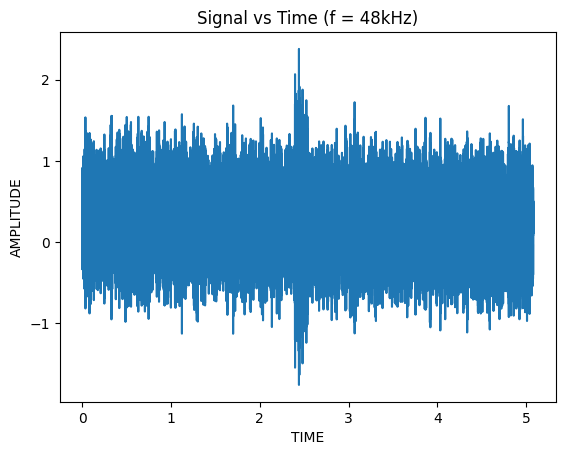

In [ ]:
freq = 48*1000  #hz
T = 1/freq
time = np.arange(0,len(df2)*T,T)

plt.plot(time, df2)
plt.xlabel("TIME")
plt.ylabel("AMPLITUDE")
plt.title("Signal vs Time (f = 48kHz)")
plt.show()

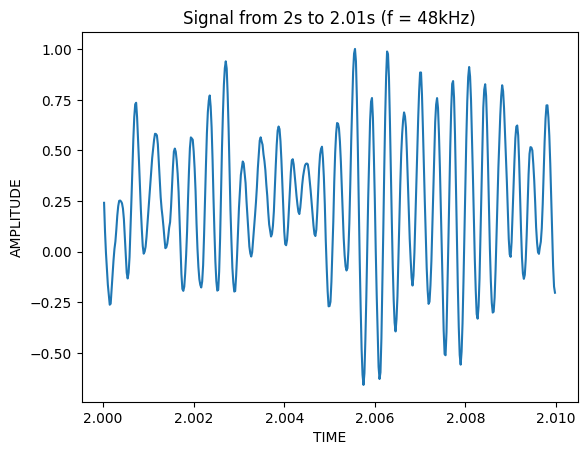

In [ ]:
filter = (time>2) & (time<2.01)
time_filtered = time[filter]
df2_filtered = df2[filter]

plt.plot(time_filtered, df2_filtered)
plt.xlabel("TIME")
plt.ylabel("AMPLITUDE")
plt.title("Signal from 2s to 2.01s (f = 48kHz)")
plt.show()

# FFT

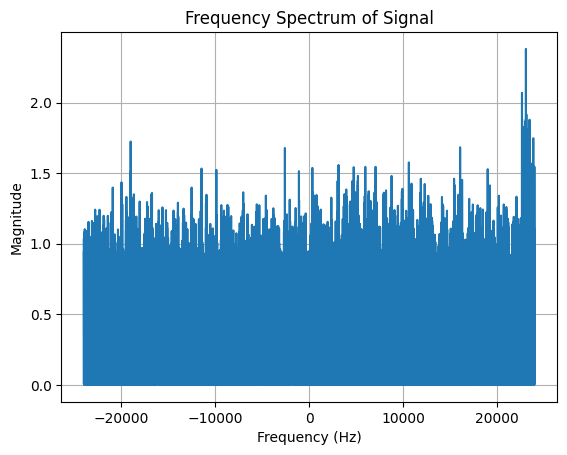

In [ ]:
def plot_fft(signal, sampling_rate):
  # FOURIE TRANSFER
  N = len(signal)
  fft_values = np.fft.fft(signal)
  fft_Magnitude = np.abs(fft_values)

  # FREQUENCY
  freq = np.fft.fftfreq(N, d=1/sampling_rate)

  # PLOTTING
  plt.plot(freq, fft_Magnitude)
  plt.xlabel("Frequency (Hz)")
  plt.ylabel("Magnitude")
  plt.title("Frequency Spectrum of Signal")
  plt.grid()
  plt.show()

sampling_rate = freq   #48000 hz
plot_fft(df2, sampling_rate)


# Segmentation

In [ ]:
def segment_signal(signal, segment_size=128, overlap=64):
  step = segment_size - overlap
  num_segment = (len(signal)-overlap)//step  #Avalible Number of Segments

  segment_array = np.zeros((num_segment, segment_size))  # Generating empty array

  for i in range(num_segment):
    start_index = i * step
    end_index = start_index + segment_size
    segment_array[i,:] = signal[start_index:end_index]

  return segment_array
df2 = df2.flatten()
segments = segment_signal(df2)

segments

array([[ 0.171524  ,  0.326772  ,  0.49161867, ...,  0.0626    ,
        -0.03046533, -0.04924533],
       [ 0.84802133,  0.91688133,  0.912708  , ...,  0.02170133,
         0.09974267,  0.17444533],
       [-0.02211867,  0.04465467,  0.14564933, ...,  0.23203733,
         0.20658   ,  0.17194133],
       ...,
       [-0.289212  , -0.27585733, -0.22494267, ..., -0.35723733,
        -0.28629067, -0.16067333],
       [ 0.599708  ,  0.43027067,  0.27251867, ..., -0.334284  ,
        -0.257912  , -0.11059333],
       [-0.010016  ,  0.08555333,  0.202824  , ...,  0.320512  ,
         0.21075333,  0.086388  ]])

# Pandas Lib

In [ ]:
df_segments = pd.DataFrame(segments)
df_segments.to_csv("Segmented_Signal.csv", index = False)
df_segments.head()

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0.171524,0.326772,0.491619,0.634347,0.729499,0.764555,0.749948,0.677332,0.550880,0.367671,...,0.642276,0.693608,0.700285,0.657717,0.549628,0.381860,0.209919,0.062600,-0.030465,-0.049245
1,0.848021,0.916881,0.912708,0.839675,0.722404,0.574251,0.416499,0.251235,0.098491,-0.019197,...,0.209919,0.140224,0.091813,0.059261,0.017528,-0.009599,-0.011685,0.021701,0.099743,0.174445
2,-0.022119,0.044655,0.145649,0.282117,0.441121,0.571747,0.669403,0.735341,0.750365,0.729081,...,0.345969,0.360993,0.368088,0.346804,0.305905,0.271684,0.250400,0.232037,0.206580,0.171941
3,0.249148,0.313835,0.363497,0.429019,0.481185,0.512903,0.528761,0.505391,0.466161,0.396884,...,0.095569,-0.027961,-0.117688,-0.174028,-0.178201,-0.116019,-0.001669,0.146901,0.300480,0.445712
4,0.161091,0.187383,0.221604,0.263755,0.287125,0.290881,0.317591,0.356820,0.405648,0.464492,...,0.274188,0.249148,0.234959,0.254573,0.290047,0.313417,0.313835,0.306323,0.298811,0.309661


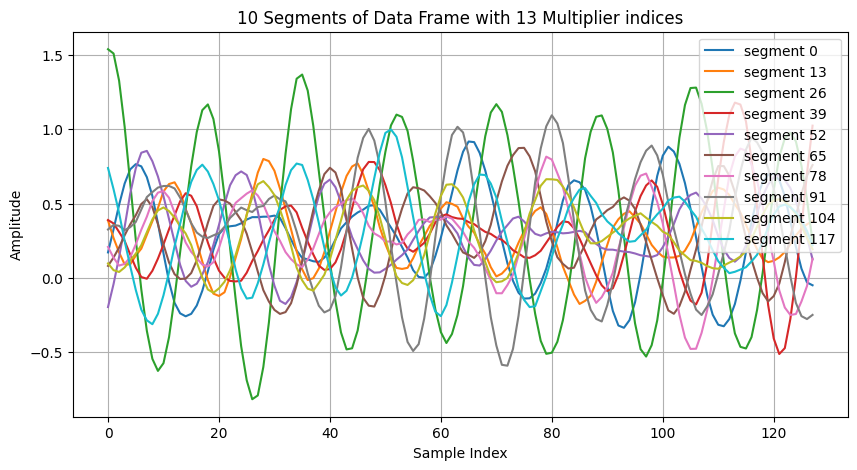

In [ ]:
num_segment = len(df_segments)

selected_indices = [i for i in range(0, num_segment, 13)][:10]  #Chosing 10 segments with indices 0, 13, 26, 39, ..., 117

colors = plt.get_cmap('tab10', 10).colors   #generating 10 diffrent colors

plt.figure(figsize=(10,5))

for index, segment_index in enumerate(selected_indices):
  plt.plot(df_segments.iloc[segment_index], label=f'segment {segment_index}', color = colors[index])


plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title("10 Segments of Data Frame with 13 Multiplier indices")
plt.legend()
plt.grid(True)

# Feature Extraction

In [ ]:
def signal_statistics(signal):
  signal = signal.flatten()   # Making sure that signal is 1D

  mean_value = np.mean(signal)
  std_value = np.std(signal)
  rms_value = np.sqrt(np.mean(signal**2))

  return mean_value, std_value, rms_value



In [ ]:
feature_list = []

for i in range(len(df_segments)):
  mean, std, rms = signal_statistics(df_segments.iloc[i].values)
  feature_list.append([mean, std, rms])

df2_feature = pd.DataFrame(feature_list, columns=["Mean", "Standard Deviation", "RMS"])

df2_feature.head()

,Mean,Standard Deviation,RMS
0,0.281302,0.320273,0.426270
1,0.287076,0.310610,0.422956
2,0.318334,0.181483,0.366432
3,0.316551,0.198186,0.373473
4,0.304334,0.262659,0.402006


In [ ]:
df2_feature.to_csv("Signal_Features.csv", index=False)